# Business Problem

The company wants to understand customer purchasing behavior during the Diwali season to:

• Identify high-value customer segments  
• Optimize inventory planning  
• Improve targeted marketing strategies  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [2]:
df = pd.read_csv(
    "C:/Users/User/OneDrive/Desktop/Diwali anlysis -python/Diwali Sales Data.csv",
    encoding='latin1'
)
df.head()


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


#  Data Cleaning

In [3]:
df.shape

(11251, 15)

In [4]:
df.isnull().sum()


User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [6]:
df.drop(['Status','unnamed1'],axis=1 ,inplace=True)

In [7]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.dtypes

User_ID               int64
Cust_name               str
Product_ID              str
Gender                  str
Age Group               str
Age                   int64
Marital_Status        int64
State                   str
Zone                    str
Occupation              str
Product_Category        str
Orders                int64
Amount              float64
dtype: object

In [10]:
df['Amount']=df['Amount'].astype(int)

In [11]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

In [12]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [13]:
df[['Amount','Age','Orders']].describe()

,Amount,Age,Orders
count,11239.000000,11239.000000,11239.000000
mean,9453.610553,35.410357,2.489634
std,5222.355168,12.753866,1.114967
min,188.000000,12.000000,1.000000
25%,5443.000000,27.000000,2.000000
50%,8109.000000,33.000000,2.000000
75%,12675.000000,43.000000,3.000000
max,23952.000000,92.000000,4.000000


# Exploratory Data Analysis

# Gender

In [14]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

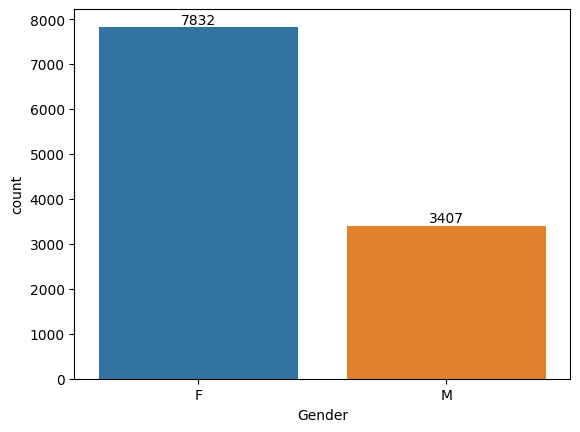

In [15]:

ax = sns.countplot(x='Gender', data=df, hue='Gender', legend=False)

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

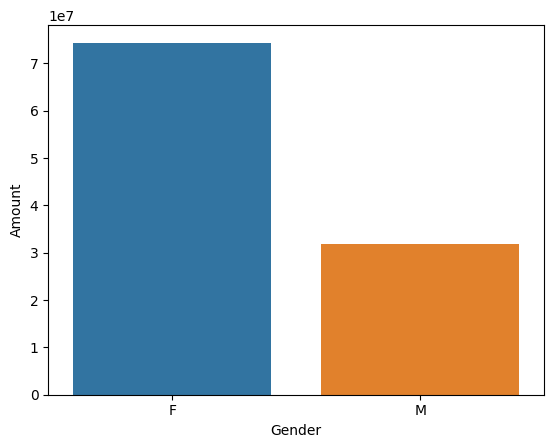

In [16]:
sale_gen=df.groupby(['Gender'], as_index= False )['Amount'].sum().sort_values(by='Amount',ascending =False)


sns.barplot(x='Gender',y='Amount',data=sale_gen, hue='Gender', legend=False)

From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater then men

# Age

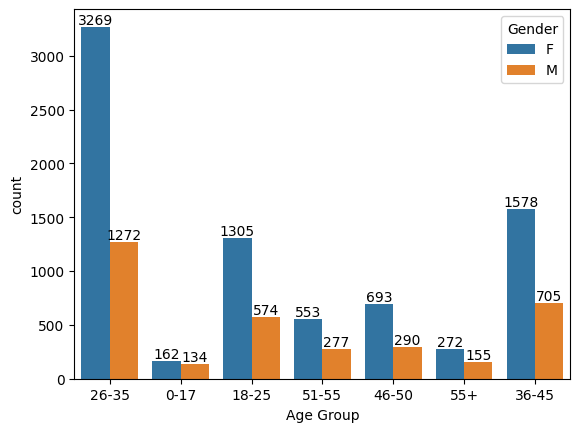

In [17]:
ax = sns.countplot(data=df,x='Age Group',hue ='Gender')
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

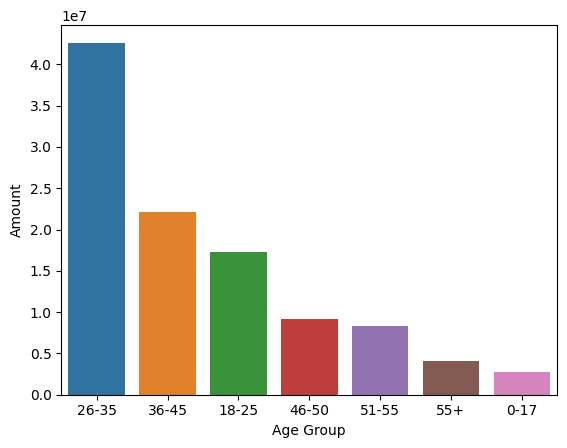

In [18]:
sale_age=df.groupby(['Age Group'], as_index= False )['Amount'].sum().sort_values(by='Amount',ascending =False)


sns.barplot(x='Age Group',y='Amount',data=sale_age, hue='Age Group')

From above graphs we can see that most of the buyers are age group between 26-35 years female

# State

<Axes: xlabel='State', ylabel='Orders'>

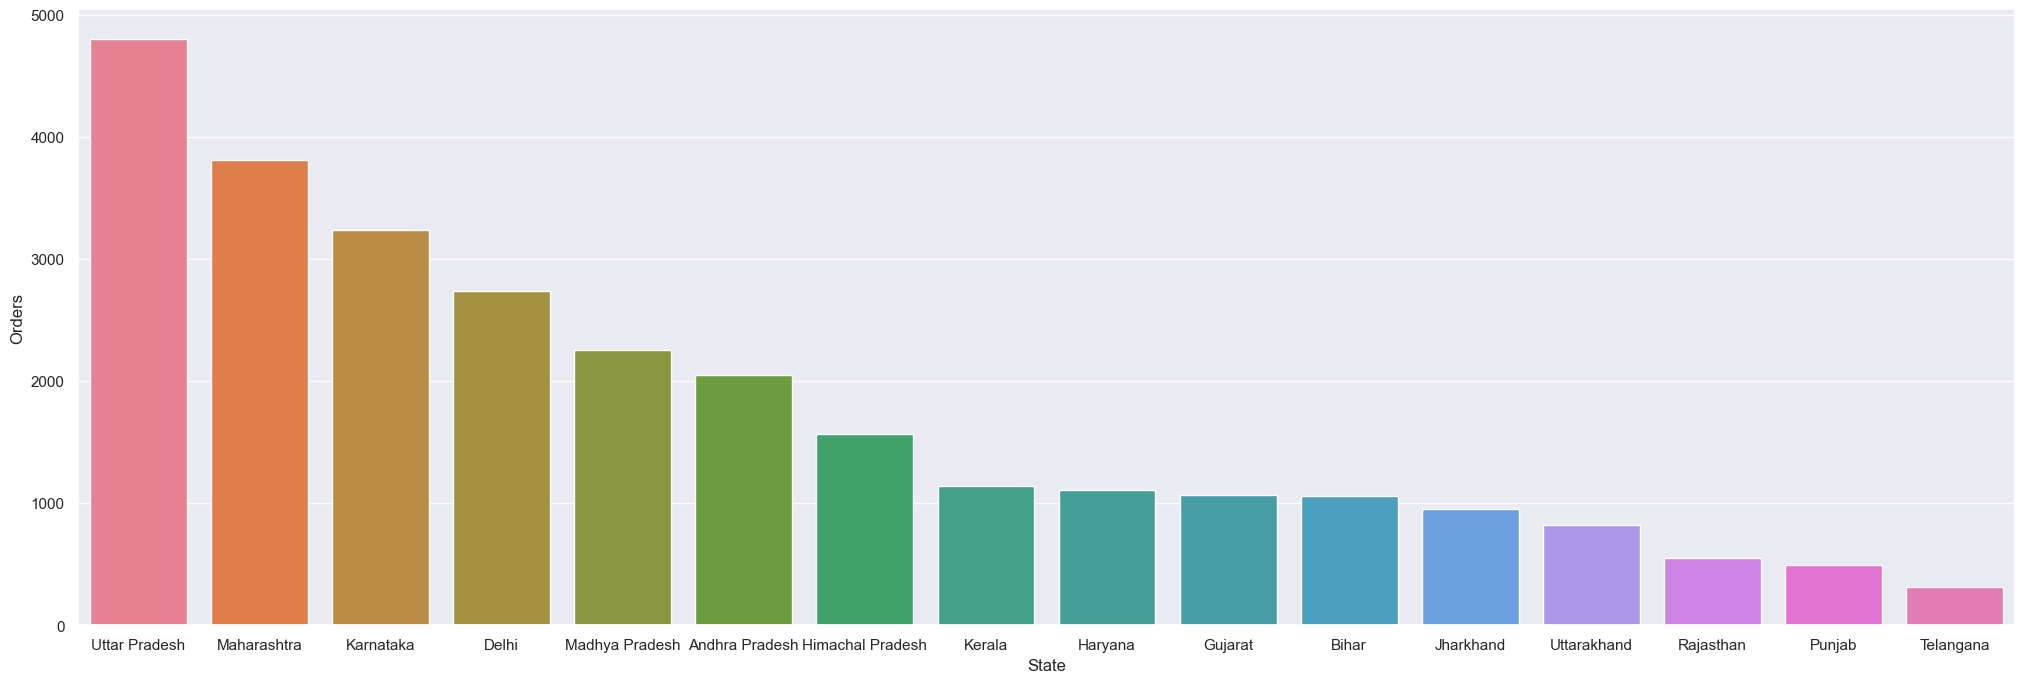

In [19]:
sale_state=df.groupby(['State'], as_index= False )['Orders'].sum().sort_values(by='Orders',ascending =False)
sns.set(rc={'figure.figsize':(25,8)})

sns.barplot(x='State',y='Orders',data=sale_state, hue='State')

<Axes: xlabel='State', ylabel='Amount'>

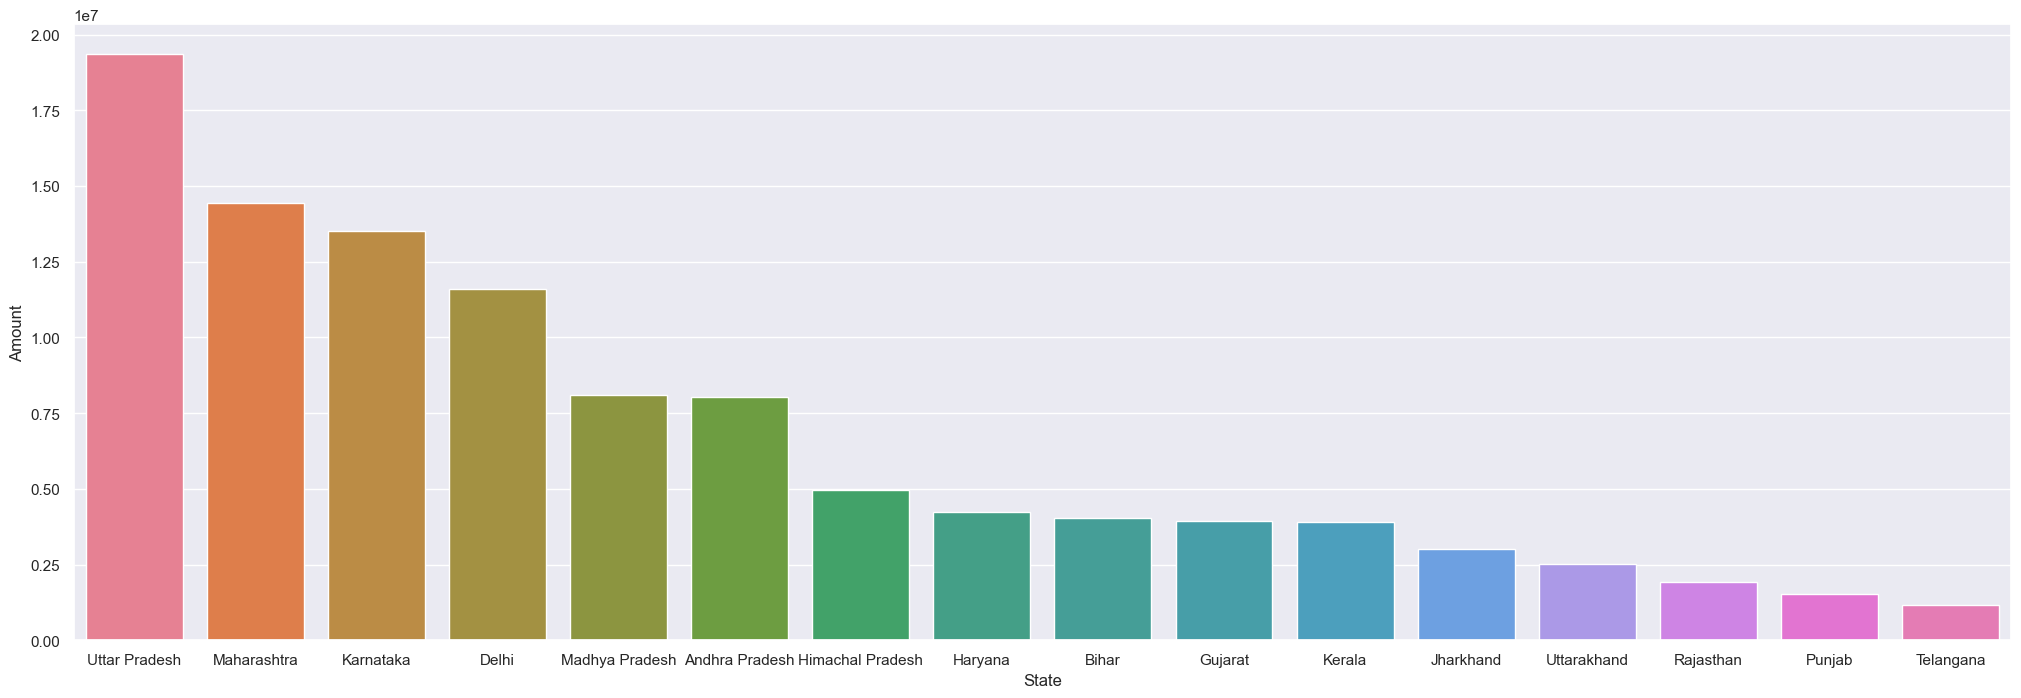

In [20]:
sale_state=df.groupby(['State'], as_index= False )['Amount'].sum().sort_values(by='Amount',ascending =False)

sns.set(rc={'figure.figsize':(25,8)})
sns.barplot(x='State',y='Amount',data=sale_state, hue='State', legend=False)

From above graphs we can see that unexpectedly most of the oders are from Utter Pradesh , Maharashtra and Karnataka respectively


# Marital Status

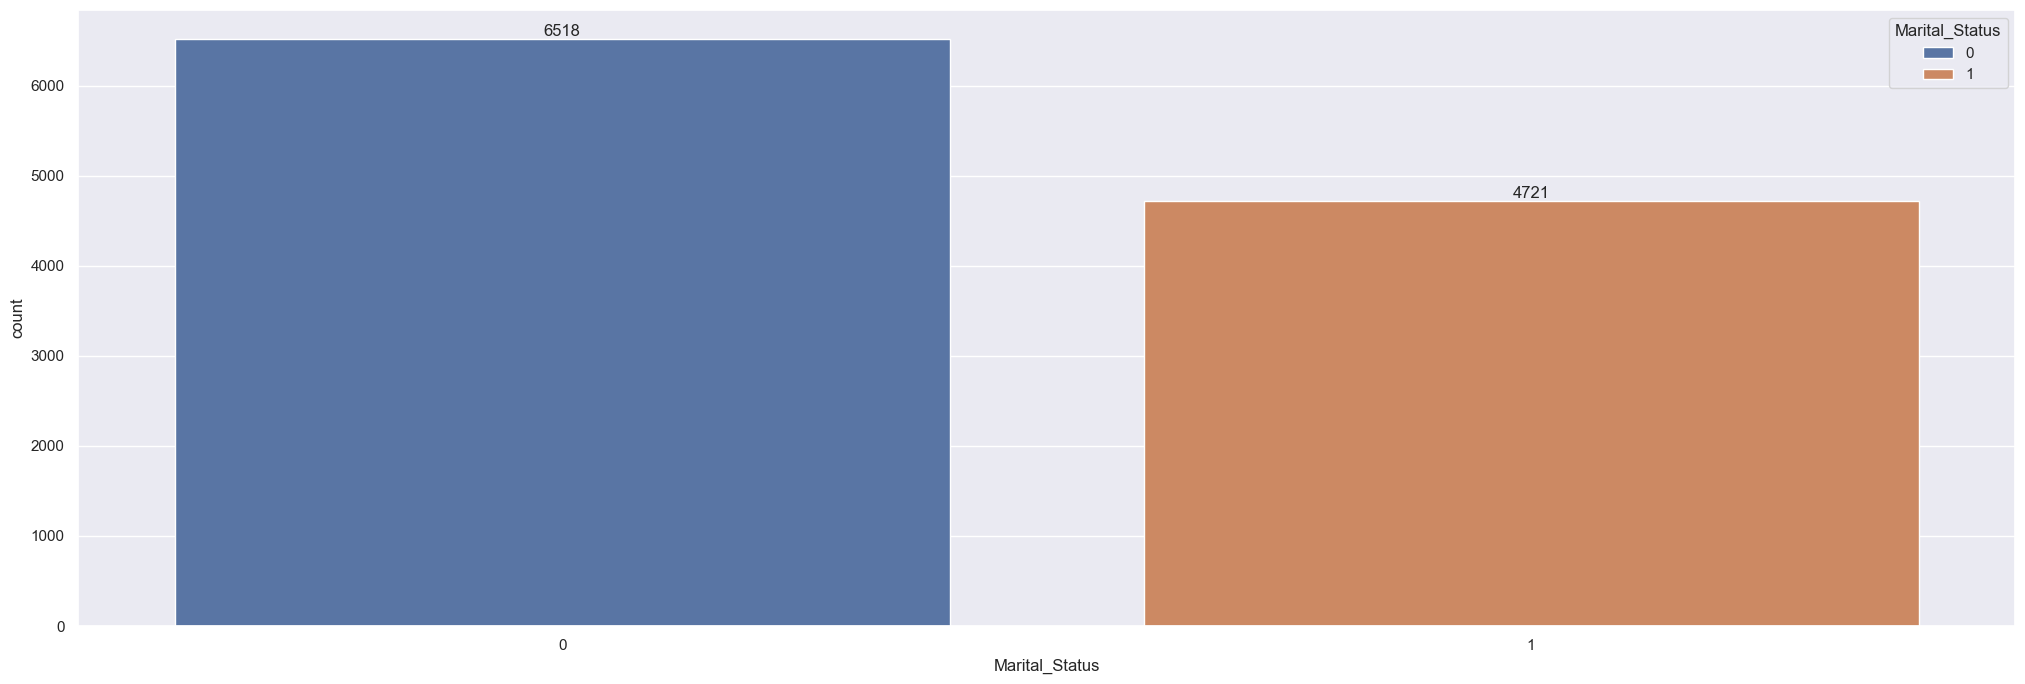

In [21]:
ax = sns.countplot(x='Marital_Status', data=df,hue='Marital_Status')
sns.set(rc={'figure.figsize':(5,5)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

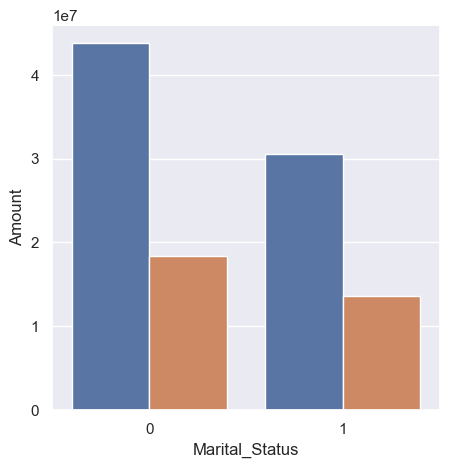

In [22]:
sale_marital=df.groupby(['Marital_Status','Gender'], as_index= False )['Amount'].sum().sort_values(by='Amount',ascending =False)

sns.set(rc={'figure.figsize':(5,5)})
sns.barplot(x='Marital_Status',y='Amount',data=sale_marital, hue='Gender', legend=False)

From above graphs we can see that most of the buyers are married(women) and they have high purchasing power

# Occupation

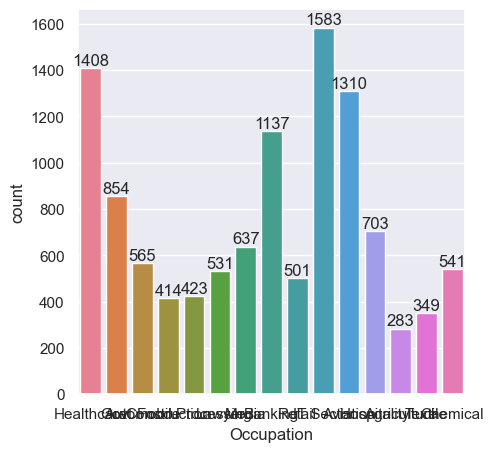

In [23]:
ax = sns.countplot(x='Occupation', data=df,hue='Occupation')
sns.set(rc={'figure.figsize':(25,8)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

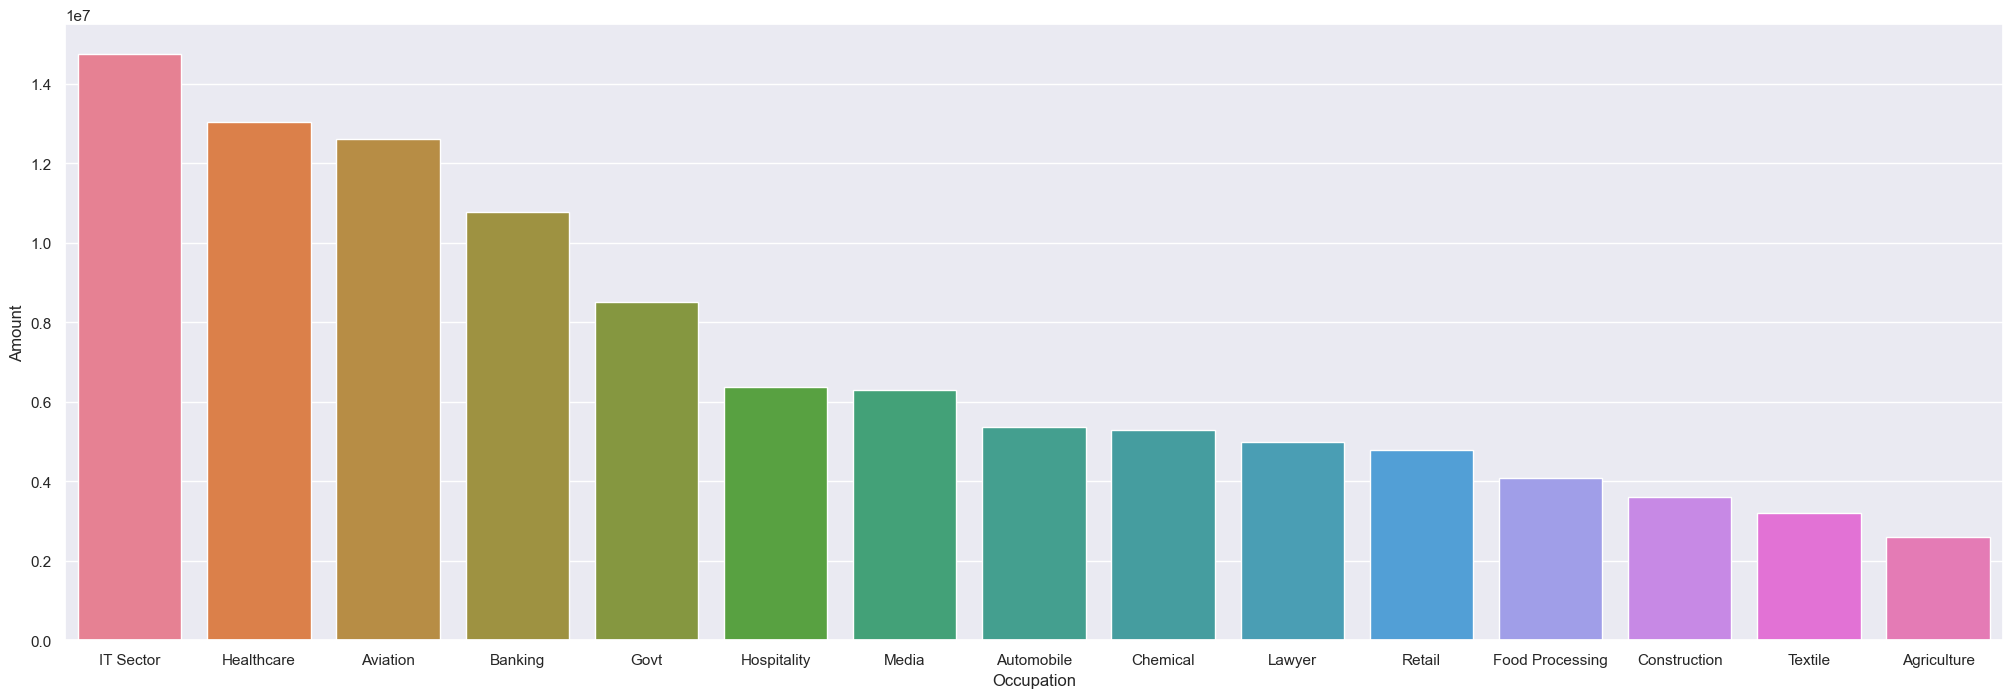

In [24]:
sale_occ=df.groupby(['Occupation'], as_index= False )['Amount'].sum().sort_values(by='Amount',ascending =False)

sns.set(rc={'figure.figsize':(25,8)})
sns.barplot(x='Occupation',y='Amount',data=sale_occ, hue='Occupation', legend=False)

*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

# Product Category

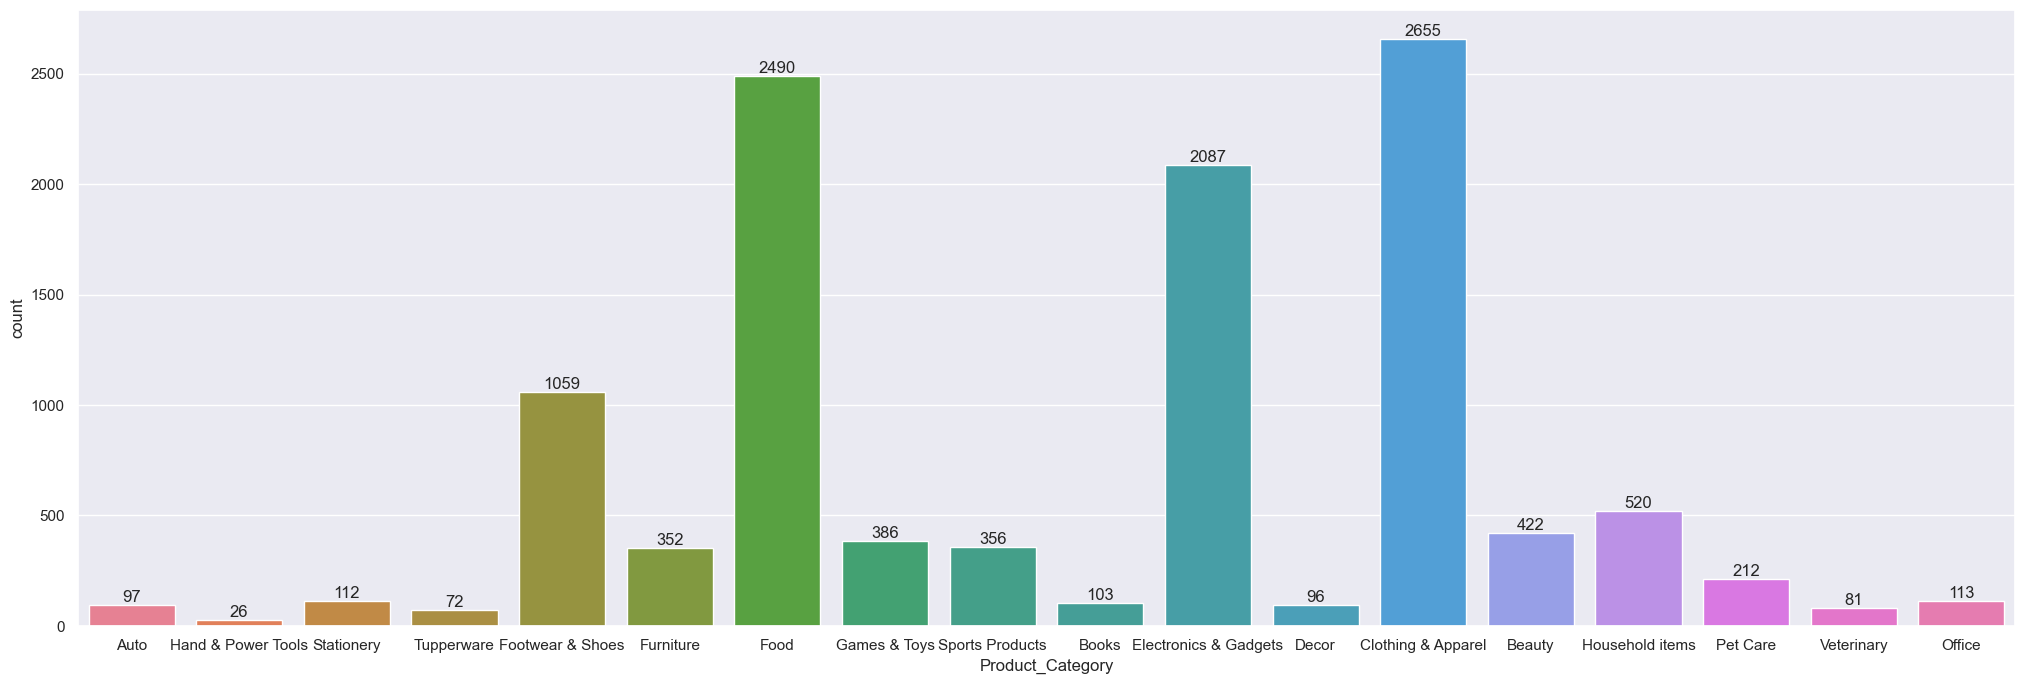

In [25]:
sns.set(rc={'figure.figsize':(25,8)})
ax = sns.countplot(data = df, x = 'Product_Category',hue ='Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

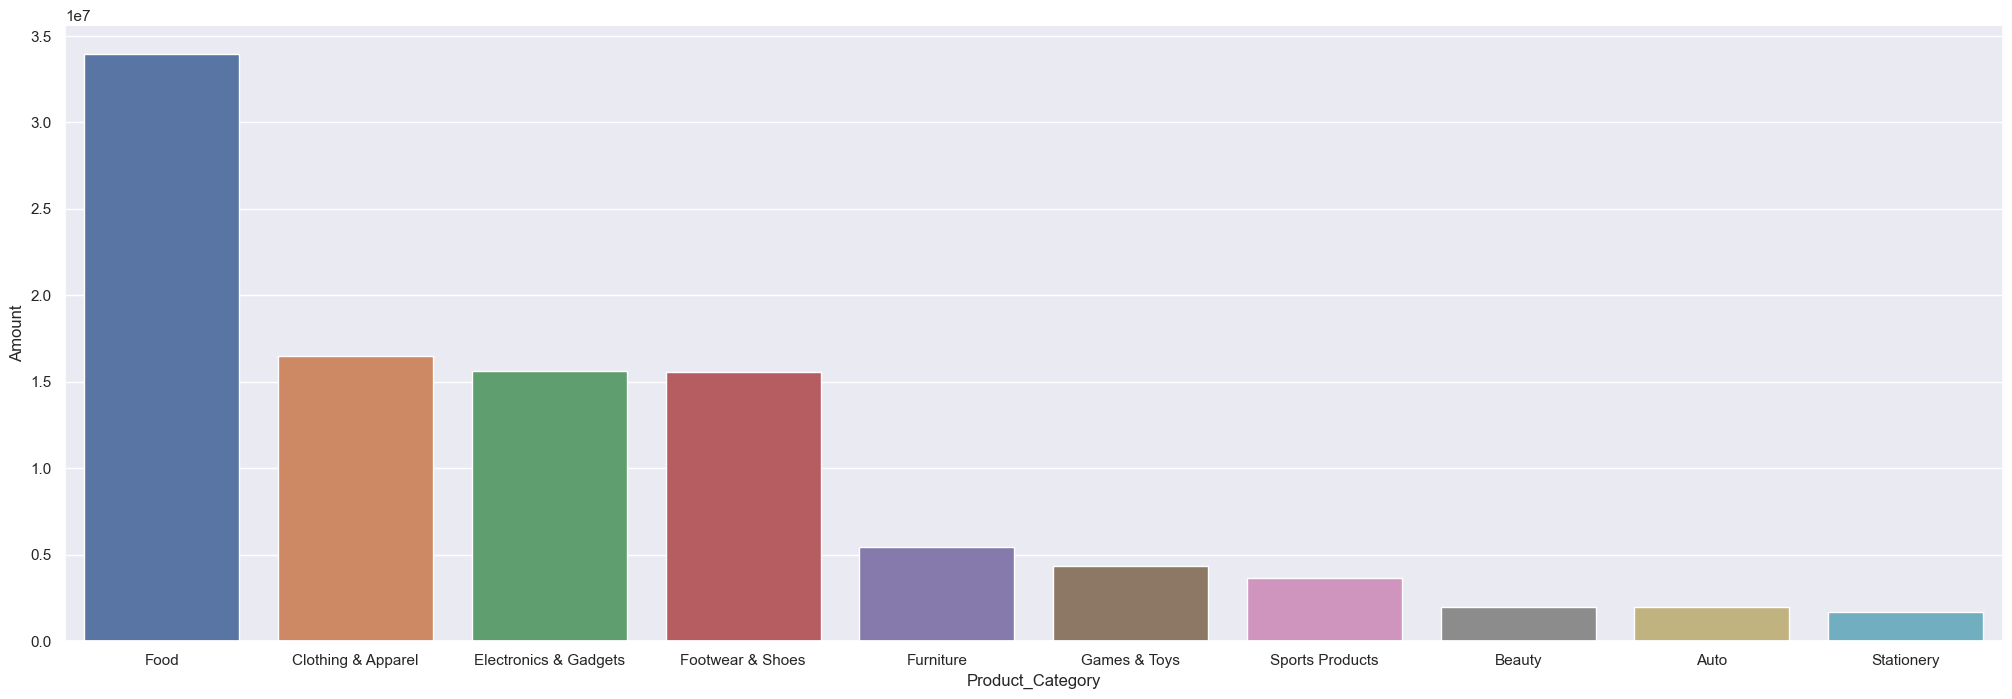

In [26]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(25,8)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount',hue='Product_Category')

From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category

<Axes: xlabel='Product_ID', ylabel='Orders'>

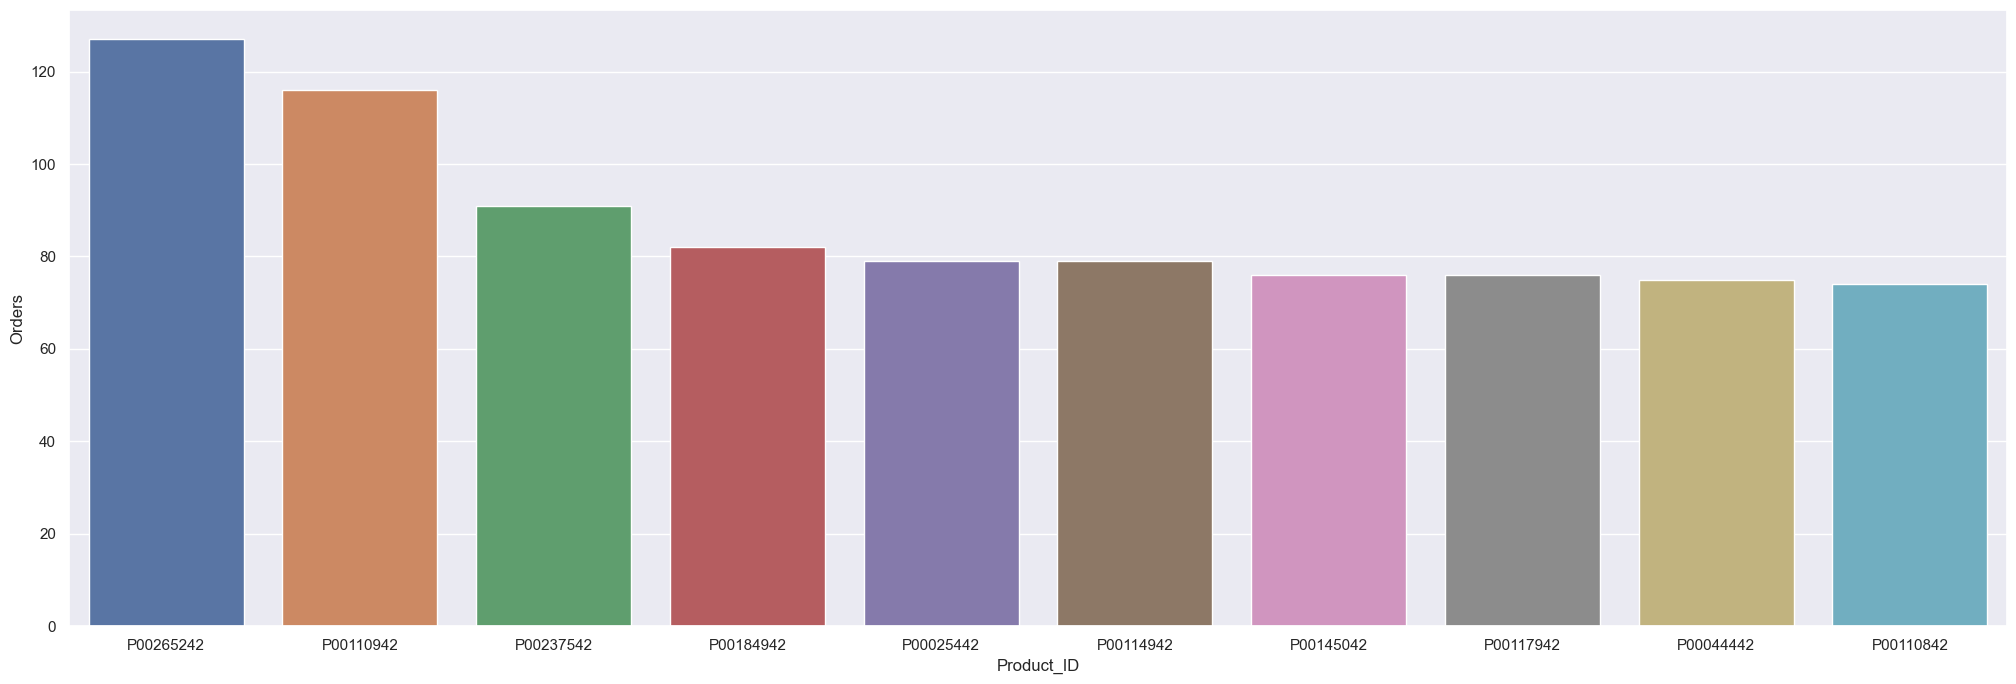

In [27]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(25,8)})
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders',hue = 'Product_ID')

# Correlation Analysis

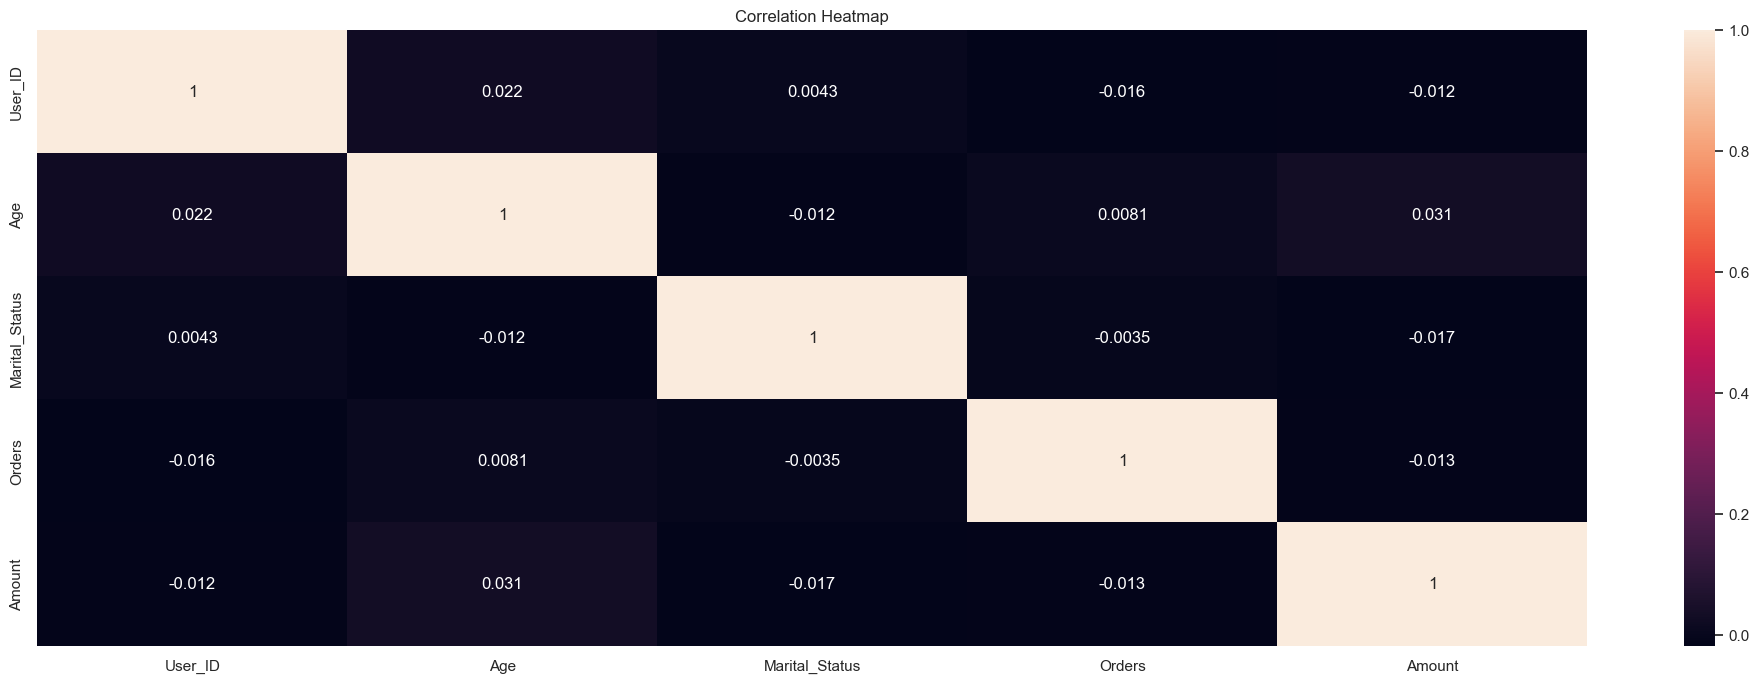

In [28]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


#  KPI Calculation

In [29]:
total_revenue = df['Amount'].sum()
total_customers = df['User_ID'].nunique()
avg_order_value = df['Amount'].mean()
top_state = df.groupby('State')['Amount'].sum().idxmax()
top_category = df.groupby('Product_Category')['Amount'].sum().idxmax()

print("Total Revenue:", total_revenue)
print("Total Customers:", total_customers)
print("Average Order Value:", avg_order_value)
print("Top State:", top_state)
print("Top Category:", top_category)


Total Revenue: 106249129
Total Customers: 3752
Average Order Value: 9453.610552540262
Top State: Uttar Pradesh
Top Category: Food


# Customer Segmentation

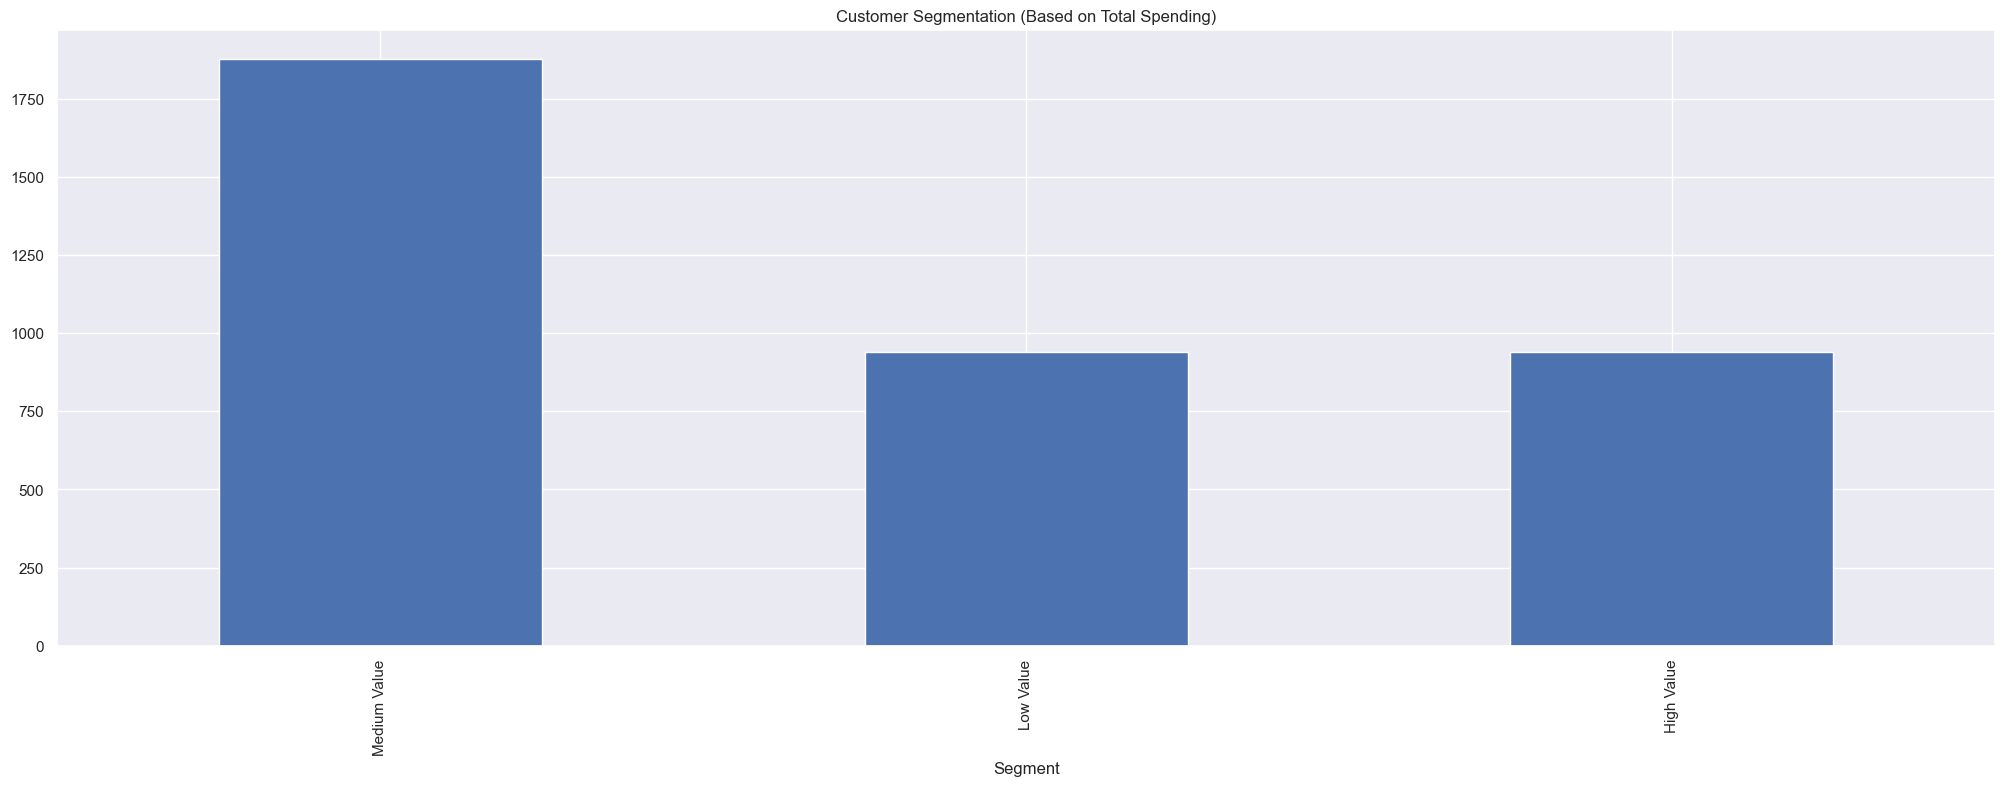

In [30]:
customer_total = df.groupby('User_ID')['Amount'].sum().reset_index()
q1 = customer_total['Amount'].quantile(0.25)
q3 = customer_total['Amount'].quantile(0.75)
def segment(x):
    if x >= q3:
        return "High Value"
    elif x >= q1:
        return "Medium Value"
    else:
        return "Low Value"

customer_total['Segment'] = customer_total['Amount'].apply(segment)
customer_total['Segment'].value_counts()
customer_total['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segmentation (Based on Total Spending)")
plt.show()


Customers are segmented into High, Medium, and Low value groups based on total purchase amount.
High-value customers contribute significantly to overall revenue and should be targeted for loyalty programs and premium offers.


In [31]:
from scipy.stats import ttest_ind

married = df[df['Marital_Status']==1]['Amount'].dropna()
unmarried = df[df['Marital_Status']==0]['Amount'].dropna()

t_stat, p_value = ttest_ind(married, unmarried)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)


T-Statistic: -1.8546608578233836
P-Value: 0.06367084895735223


# Hypothesis Testing: Impact of Marital Status on Spending

H0 (Null Hypothesis): There is no significant difference in average spending between married and unmarried customers.

H1 (Alternative Hypothesis): There is a significant difference in average spending between married and unmarried customers.


In [32]:
print("Average Spending (Married):", round(married.mean(),2))
print("Average Spending (Unmarried):", round(unmarried.mean(),2))


Average Spending (Married): 9346.27
Average Spending (Unmarried): 9531.36


In [33]:
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis")
    print("Conclusion: Marital status significantly affects spending behavior.")
else:
    print("Result: Fail to Reject the Null Hypothesis")
    print("Conclusion: No significant difference in spending based on marital status.")


Result: Fail to Reject the Null Hypothesis
Conclusion: No significant difference in spending based on marital status.


## Interpretation of Hypothesis Test

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

This indicates that marital status does not significantly influence purchasing behavior during the Diwali season.

Therefore, marketing strategies should focus more on other demographic factors such as age group and state rather than marital segmentation.


# Conclusion



This analysis was conducted to understand customer purchasing behavior during the Diwali festive season and identify key revenue-driving factors.

# Key Findings

1. *High-value customers contribute a major portion of total revenue**, making them critical for loyalty programs and targeted marketing strategies.

2. The *26–35 age group shows strong purchasing behavior**, indicating high spending potential during festive seasons.

3. *Food and Clothing categories generate the highest sales**, reflecting strong festive demand in these segments.

4. Statistical testing shows that **marital status does not significantly impact spending behavior**, suggesting that marketing strategies should focus more on age group and regional segmentation.


# Business Recommendations

- Increase inventory for top-performing product categories before festive seasons.
- Focus marketing campaigns on high-revenue states.
- Design personalized offers for high-value customers.
- Use data-driven insights to optimize festive sales strategy.
